### ====== Loading, Reconstructing and Visualizing the fastMRI Prostate dataset ====== 

#### To download the fastMRI prostate dataset: https://fastmri.med.nyu.edu/

In [1]:
import argparse
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
from typing import Tuple

import xml.etree.ElementTree as etree
from fastmri_prostate.reconstruction.t2.prostate_t2_recon import t2_reconstruction
from fastmri_prostate.reconstruction.dwi.prostate_dwi_recon import dwi_reconstruction_diffusion
from fastmri_prostate.data.mri_data import load_file_T2, load_file_dwi, save_recon
from fastmri_prostate.data.mri_data import load_dat_file_T2, load_file_dwi, save_recon

import warnings
import os
warnings.filterwarnings('ignore')



/gpfs/scratch/td2105/conda_envs/prostate_kspace/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#! Below: Add full folder path to downloaded fastMRI prostate data
fastMRI_dir = "/gpfs/data/chopralab/dat_files"

data_path_t2 = 'Hersh_VidaProstate#SNotGiven#F290393#M1154#D220623#T190227#AXT2_HVP.dat'
data_path_dwi = 'fastMRI_prostate_DIFF_IDS_001_011'

The fastMRI Prostate dataset is distributed as a set of HDF5 files that can be read with the h5py package

In [3]:
fname_t2 = Path(fastMRI_dir) / data_path_t2
#fname_dwi = os.path.join(fastMRI_dir,data_path_dwi, 'file_prostate_AXDIFF_001.h5')

In [4]:
fname_t2

PosixPath('/gpfs/data/chopralab/dat_files/Hersh_VidaProstate#SNotGiven#F290393#M1154#D220623#T190227#AXT2_HVP.dat')

## ---------------------------- T2  ----------------------------

### Example - how to load, reconstruct and visualize the T2 data. Data dimensions are explained here as well.

In [5]:
kspace, calibration_data, hdr = load_dat_file_T2(fname_t2)

print("Sizes of the array fields in the fastMRI prostate T2 file:")
print("kspace:", kspace.shape, ", calibration_data:", calibration_data.shape,)

Software version: VD/VE (!?)

Scan  0
100 % parsed in 1 s. Estimated 0 s remaining.
Scan  1
100 % parsed in 18 s. Estimated 0 s remaining.
Sizes of the array fields in the fastMRI prostate T2 file:
kspace: (3, 30, 20, 640, 451) , calibration_data: (30, 20, 640, 241)


Description of fields in the fastMRI prostate T2 file:

- "ismrmrd_header" => ISMRMRD header => scan acquisition parameters (https://ismrmrd.github.io/apidocs/1.5.0/)
- "kspace" => T2 raw k-space with dimensions => averages, slices, coils, readout, phase
- "reconstruction_rss" => Reconstructed T2 image volume with dimensions => slices, x, y
- "calibration_data" => Calibration scan acquired with dimensions => slices, coils, readout, phase

In [6]:
hdr.keys()

dict_keys(['Config', 'Dicom', 'Meas', 'MeasYaps', 'Phoenix', 'Protocol', 'Spice'])

#### T2 reconstruction takes as input the kspace, calibration data and the ISMRMRD header => to outputs a dictionary containing the reconstructed image

In [7]:
%%time
img_dict_t2 = t2_reconstruction(kspace, calibration_data, hdr)
print("Size of reconstructed data:")
print(img_dict_t2['reconstruction_rss'].shape)

Size of reconstructed data:
(30, 320, 320)
CPU times: user 14min 38s, sys: 5min 2s, total: 19min 40s
Wall time: 8min 40s


### Plotting the reconstructed T2 image, which is the same as 'reconstruction_rss' present in the h5 file

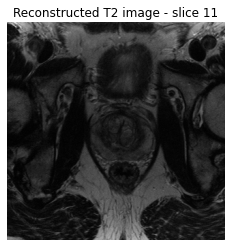

In [9]:
def display_t2_slice(img, slice_num):
    plt.imshow(img[slice_num, :, :] , cmap='gray')
    plt.title("Reconstructed T2 image - slice 11")
    plt.axis("off")
display_t2_slice(img_dict_t2['reconstruction_rss'], 15)

## ---------------------------- DWI  ----------------------------

### Example - how to load, reconstruct and visualize the DWI data. Data dimensions are explained here as well.

In [31]:
kspace, calibration_data, coil_sens_maps, ismrmrd_header = load_file_dwi(fname_dwi)

print("Sizes of the array fields in the fastMRI prostate DWI file:")
print("kspace:", kspace.shape, ", calibration_data:", calibration_data.shape, ", coil_sens_maps:", coil_sens_maps.shape)

Sizes of the array fields in the fastMRI prostate DWI file:
kspace: (50, 30, 20, 200, 150) , calibration_data: (30, 20, 200, 32) , coil_sens_maps: (30, 20, 200, 150)


Description of fields in the fastMRI prostate DWI file:

- "ismrmrd_header" => ISMRMRD header => scan acquisition parameters (https://ismrmrd.github.io/apidocs/1.5.0/)
- "kspace" => T2 raw k-space with dimensions => diffusion*, slices, coils, readout, phase
- "calibration_data" => Calibration scan acquired with dimensions => slices, coils, readout, phase
- "coil_sens_maps" => Coil sensitivity maps calculated using ESPIRIT with dimensions  => slices, coils, readout, phase

*diffusion dimension is comprised of multiple averages for different B strengths, they can be parsed out in the following way:

- B0_avg1   => kspace[0,:]
- B0_avg2   => kspace[1,:]
- B50x_avg1 => kspace[2,:]
- B50x_avg2 => kspace[8,:]
- B50x_avg3 => kspace[14,:]
- B50x_avg4 => kspace[20,:]
- B50y_avg1 => kspace[3,:]
- B50y_avg2 => kspace[9,:]
- B50y_avg3 => kspace[15,:]
- B50y_avg4 => kspace[21,:]
- B50z_avg1 => kspace[4,:]
- B50z_avg2 => kspace[10,:]
- B50z_avg3 => kspace[16,:]
- B50z_avg4 => kspace[22,:]
- B1000x_avg1 => kspace[5,:]
- B1000x_avg2 => kspace[11,:]
- B1000x_avg3 => kspace[17,:]
- B1000x_avg4 => kspace[23,:]
- B1000x_avg5 => kspace[26,:]
- B1000x_avg6 => kspace[29,:]
- B1000x_avg7 => kspace[32,:]
- B1000x_avg8 => kspace[35,:]
- B1000x_avg9 => kspace[38,:]
- B1000x_avg10 => kspace[41,:]
- B1000x_avg11 => kspace[44,:]
- B1000x_avg12 => kspace[47,:]
- B1000y_avg1 => kspace[6,:]
- B1000y_avg2 => kspace[12,:]
- B1000y_avg3 => kspace[18,:]
- B1000y_avg4 => kspace[24,:]
- B1000y_avg5 => kspace[27,:]
- B1000y_avg6 => kspace[30,:]
- B1000y_avg7 => kspace[33,:]
- B1000y_avg8 => kspace[36,:]
- B1000y_avg9 => kspace[39,:]
- B1000y_avg10 => kspace[42,:]
- B1000y_avg11 => kspace[45,:]
- B1000y_avg12 => kspace[48,:]
- B1000z_avg1 => kspace[7,:]
- B1000z_avg2 => kspace[13,:]
- B1000z_avg3 => kspace[19,:]
- B1000z_avg4 => kspace[25,:]
- B1000z_avg5 => kspace[28,:]
- B1000z_avg6 => kspace[31,:]
- B1000z_avg7 => kspace[34,:]
- B1000z_avg8 => kspace[37,:]
- B1000z_avg9 => kspace[40,:]
- B1000z_avg10 => kspace[43,:]
- B1000z_avg11 => kspace[46,:]
- B1000z_avg12 => kspace[49,:]

#### DWI reconstruction takes as input the kspace, calibration data, coil sensitivity maps and the ISMRMRD header => to outputs a dictionary containing the reconstructed images

In [36]:
%%time
img_dict_dwi = dwi_reconstruction(kspace, calibration_data, coil_sens_maps, ismrmrd_header)
print("Size of B50x image (as an example):")
print(img_dict_dwi['b50x'].shape)
print("Size of ADC map (as an example):")
print(img_dict_dwi['adc_map'].shape)

Size of B50x image (as an example):
(30, 100, 100)
Size of ADC map (as an example):
(30, 100, 100)
CPU times: user 1h 33s, sys: 56min 30s, total: 1h 57min 3s
Wall time: 6min 39s


### Plotting the reconstructed DWI images, which contained by the same field names in the h5 file

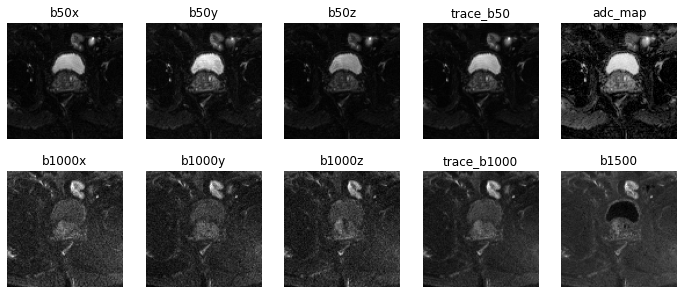

In [39]:
def display_dwi_slice(dwi_recons, slice_num):
    _, ax = plt.subplots(2, 5, figsize=(12,5))
    
    for idx, k in enumerate(['b50x', 'b50y', 'b50z', 'trace_b50', 'adc_map']):
        ax[0][idx].imshow(img_dict_dwi[k][slice_num, :, :], cmap='gray')
        ax[0][idx].title.set_text(k)
        ax[0][idx].axis("off")
    
    for idx, k in enumerate(['b1000x', 'b1000y', 'b1000z', 'trace_b1000', 'b1500']):
        ax[1][idx].imshow(img_dict_dwi[k][slice_num, :, :], cmap='gray')
        ax[1][idx].title.set_text(k)
        ax[1][idx].axis("off")

        
    plt.subplots_adjust(wspace=0.2, hspace=0.2)
    plt.show()

display_dwi_slice(img_dict_dwi, 10)

# Look at h5 files

In [35]:
def print_hdf5_tree(handle: h5py.File) -> None:
    def visitor(name, obj):
        indent = "  " * name.count("/")
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}{name} -> shape={obj.shape}, dtype={obj.dtype}")
        else:
            print(f"{indent}{name}/")
    handle.visititems(visitor)

In [38]:
import h5py
from pathlib import Path

h5_path = Path("/gpfs/scratch/td2105/dwi_esc_kspace_recon/46763999.h5")

with h5py.File(h5_path, "r") as hf:
    print_hdf5_tree(hf)
    b50x_avg = hf["images/averaged/b50x"][()] 
    b1000x_avg = hf["images/averaged/b1000x"][()]
    b50x_per_avg = hf["images/per_average/b50x"][()] 
    b1000x_per_avg = hf["images/per_average/b1000x"][()]
    b50x_kspace = hf["kspace/esc/b50x"][()]
    b1000x_kspace = hf["kspace/esc/b1000x"][()]
    esc_full = hf["images/esc_full"][()]

    directions = [d.decode() for d in hf["metadata/directions"][()]]
    averages = tuple(hf["metadata/averages"][()])

print(directions, averages)

hdr -> shape=(), dtype=object
images/
  images/averaged/
    images/averaged/b1000x -> shape=(32, 100, 100), dtype=float32
    images/averaged/b50x -> shape=(32, 100, 100), dtype=float32
  images/esc_full -> shape=(48, 32, 200, 150), dtype=float32
  images/per_average/
    images/per_average/b1000x -> shape=(12, 32, 200, 150), dtype=float32
    images/per_average/b50x -> shape=(4, 32, 200, 150), dtype=float32
kspace/
  kspace/esc/
    kspace/esc/b1000x -> shape=(12, 32, 200, 150), dtype=complex64
    kspace/esc/b50x -> shape=(4, 32, 200, 150), dtype=complex64
  kspace/post_grappa_full -> shape=(48, 32, 200, 150), dtype=complex64
metadata/
  metadata/averages -> shape=(2,), dtype=int16
  metadata/direction_indices/
    metadata/direction_indices/b1000x -> shape=(12,), dtype=int16
    metadata/direction_indices/b50x -> shape=(4,), dtype=int16
  metadata/directions -> shape=(2,), dtype=|S12
['b50x', 'b1000x'] (4, 12)


In [41]:
b50x_avg.shape, b1000x_avg.shape, b50x_per_avg.shape, b1000x_per_avg.shape, b50x_kspace.shape, b1000x_kspace.shape, esc_full.shape

((32, 100, 100),
 (32, 100, 100),
 (4, 32, 200, 150),
 (12, 32, 200, 150),
 (4, 32, 200, 150),
 (12, 32, 200, 150),
 (48, 32, 200, 150))

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

def show_dwi_overview(h5_path: Path, slice_idx: int = 16):
    with h5py.File(h5_path, "r") as hf:
        b50x_avg = hf["images/averaged/b50x"][()]
        b1000x_avg = hf["images/averaged/b1000x"][()]
        b50x_per = hf["images/per_average/b50x"][()]       # (4, slices, H, W)
        b1000x_per = hf["images/per_average/b1000x"][()]   # (12, slices, H, W)
        b50x_k = hf["kspace/esc/b50x"][()]                 # (4, slices, RO, PE)
        b1000x_k = hf["kspace/esc/b1000x"][()]

    fig, axes = plt.subplots(4, 4, figsize=(14, 12))
    axes = axes.reshape(4, 4)

    # Row 1: averaged images
    panels_row1 = [
        ("b50x avg", b50x_avg[slice_idx]),
        ("b1000x avg", b1000x_avg[slice_idx]),
    ]
    for ax, (title, img) in zip(axes[0, :2], panels_row1):
        im = ax.imshow(img, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01)
    for ax in axes[0, 2:]:
        ax.axis("off")

    # Row 2: 4 b50x averages
    for idx in range(4):
        ax = axes[1, idx]
        im = ax.imshow(b50x_per[idx, slice_idx], cmap="gray")
        ax.set_title(f"b50x avg#{idx}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01)

    # Row 3: pick every 3rd b1000x average
    b1000_indices = [0, 3, 6, 9]
    for col, avg_idx in enumerate(b1000_indices):
        ax = axes[2, col]
        im = ax.imshow(b1000x_per[avg_idx, slice_idx], cmap="gray")
        ax.set_title(f"b1000x avg#{avg_idx}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01)

    # Row 4: log-magnitude k-space for same averages
    for col in range(4):
        ax = axes[3, col]
        if col < 2:
            kdata = b50x_k[col, slice_idx]
            title = f"|k| b50x#{col}"
        else:
            idx = b1000_indices[col]
            kdata = b1000x_k[idx, slice_idx]
            title = f"|k| b1000x#{idx}"
        im = ax.imshow((np.abs(kdata))**0.2, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01)

    fig.suptitle(f"ESC overview – slice {slice_idx}")
    plt.tight_layout()
    plt.show()


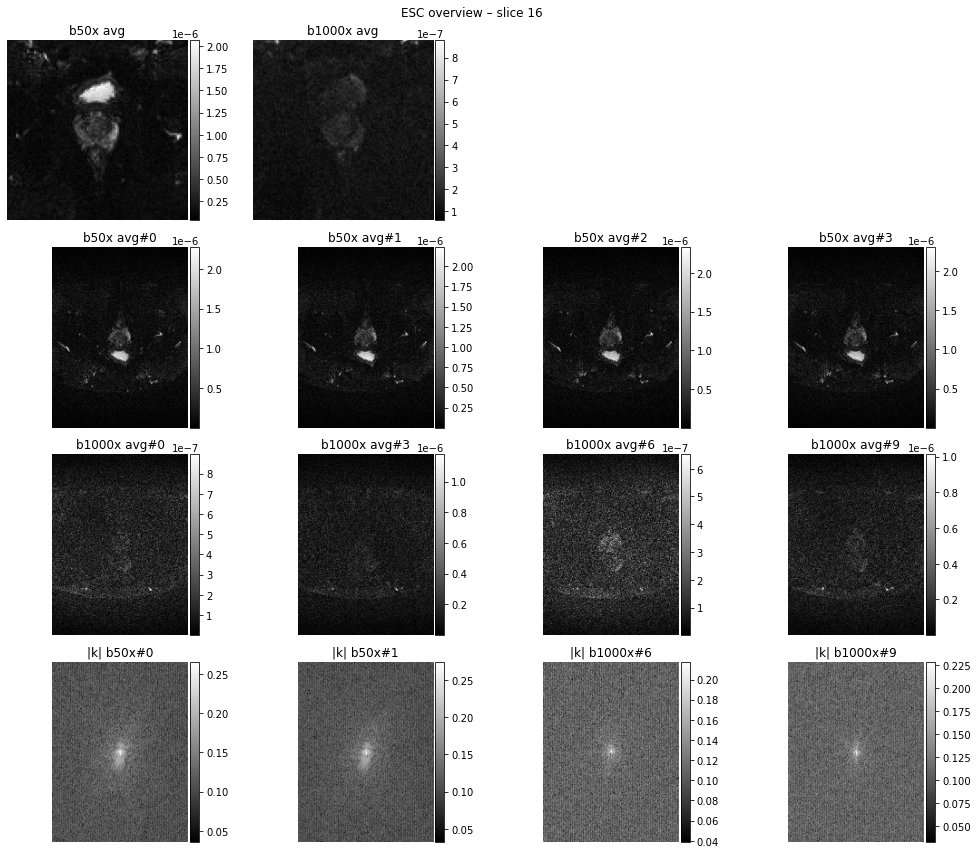

In [66]:
show_dwi_overview(Path("/gpfs/scratch/td2105/dwi_esc_kspace_recon/29637484.h5"), slice_idx=16)

## PI-RADS/Gleason Distribution for DWI kspace data

In [114]:
df_train = pd.read_csv('/gpfs/data/prostatelab/processed_data/csv/data_split/train_temporal_split_w_gleason_20240619_exclude_mismatch.csv')
df_val = pd.read_csv('/gpfs/data/prostatelab/processed_data/csv/data_split/val_temporal_split_w_gleason_20240619_exclude_mismatch.csv')
df_test = pd.read_csv('/gpfs/data/prostatelab/processed_data/csv/data_split/test_temporal_split_w_gleason_20240619_exclude_mismatch.csv')

In [115]:
df = pd.concat([df_train, df_val, df_test], axis=0)

In [116]:
df.shape

(30743, 7)

In [117]:
df_dwi = pd.read_csv('/gpfs/data/prostatelab/jhad02/raw_data_csv_file/files_to_recall_full.csv')

In [118]:
df.shape, df_dwi.shape

((30743, 7), (2304, 7))

In [119]:
df_dwi.columns

Index(['size', 'path', 'mrn', 'date', 'AccessionNumber', 'data_filename_dwi',
       'StudyDate'],
      dtype='object')

In [120]:
df.columns

Index(['PatientID', 'AccessionNumber', 'StudyDate', 'maxPIRADS',
       'rad_AccessionNumber', 'MaxGleasonScore', 'path_AccessionNumber'],
      dtype='object')

In [121]:
df_dwi_kspace = pd.merge(
    df,
    df_dwi[['path', 'mrn', 'date', 'AccessionNumber', 'data_filename_dwi']],
    on='AccessionNumber',
    how='inner'
)

In [122]:
df_dwi_kspace.shape

(1251, 11)

In [123]:
df_dwi_kspace.columns

Index(['PatientID', 'AccessionNumber', 'StudyDate', 'maxPIRADS',
       'rad_AccessionNumber', 'MaxGleasonScore', 'path_AccessionNumber',
       'path', 'mrn', 'date', 'data_filename_dwi'],
      dtype='object')

## Study Date distribution

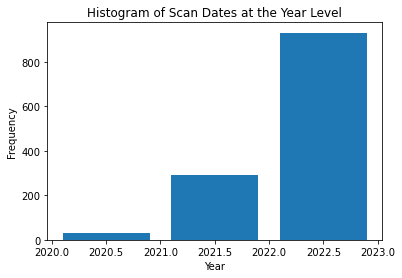

In [124]:
try:
    df_dwi_kspace['StudyDate'] = pd.to_datetime(df_dwi_kspace['StudyDate'], format='%Y%m%d', errors='raise')
except (ValueError, TypeError):
    print("Error: Unable to convert some values to datetime.")
    df_dwi_kspace['StudyDate'] = pd.to_datetime(df_dwi_kspace['StudyDate'], errors='coerce')

df_dwi_kspace['Year'] = df_dwi_kspace['StudyDate'].dt.year

df_dwi_kspace['Year'].plot(kind='hist', bins=range(int(df_dwi_kspace['Year'].min()), int(df_dwi_kspace['Year'].max() + 1)), rwidth=0.8)

plt.title('Histogram of Scan Dates at the Year Level')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.show()

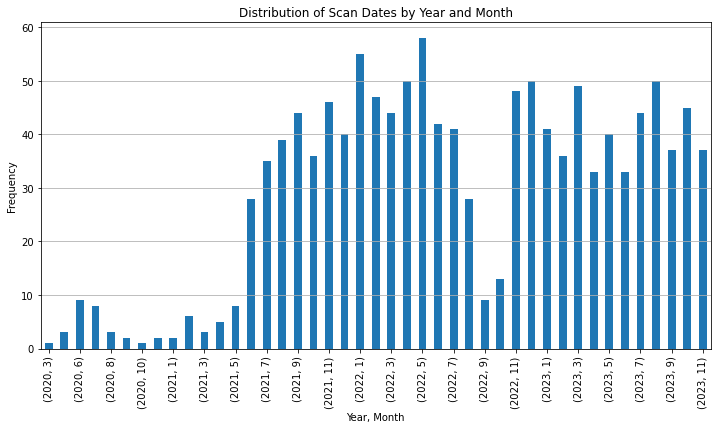

In [125]:
dates = pd.to_datetime(list(df_dwi_kspace['StudyDate']), format='%Y%m%d')

dates_df = pd.DataFrame({'Date': dates})

plt.figure(figsize=(12, 6))
dates_df.groupby([dates_df['Date'].dt.year, dates_df['Date'].dt.month]).size().plot(kind='bar')
plt.title('Distribution of Scan Dates by Year and Month')
plt.xlabel('Year, Month')
plt.ylabel('Frequency')
plt.xticks(rotation=90, ticks=plt.xticks()[0][::2])
plt.grid(axis='y')
plt.show()

## PIRADS distribution

In [126]:
from collections import Counter
pirads = Counter(df_dwi_kspace['maxPIRADS'])

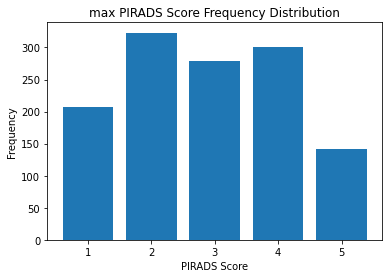

In [127]:
keys = list(pirads.keys())
values = list(pirads.values())

keys_ordered = sorted(keys, key=lambda x: float('inf') if x == 'NaN' else float(x))
values_ordered = [pirads[key] if key != 'NaN' else pirads[key] for key in keys_ordered]

plt.bar(keys_ordered, values_ordered)
plt.xlabel('PIRADS Score')
plt.ylabel('Frequency')
plt.title('max PIRADS Score Frequency Distribution')
plt.show()


## Gleason Score

In [137]:
df_dwi_kspace['MaxGleasonScore'].value_counts()

MaxGleasonScore
 6.0    405
-1.0    391
 7.0    376
 8.0     44
 9.0     35
Name: count, dtype: int64

# Check some dwi dat files

In [65]:
from fastmri_prostate.data.mri_data import load_dat_file_dwi 

In [66]:
all_metadata_csv = '/gpfs/data/prostatelab/processed_data/csv/kspace_prostate_dwi_file_metadata.csv'
df_all = pd.read_csv(all_metadata_csv)

In [67]:
METADATA_CSV='/gpfs/data/prostatelab/jhad02/raw_data_csv_file/files_to_recall_full.csv'
df_md = pd.read_csv(METADATA_CSV)

In [68]:
df_md.shape, df_all.shape

((2304, 7), (35677, 2))

In [69]:
# load a dwi file
import twixtools
p = '/gpfs/data/prostatelab/jhad02/dwi_raw_dat_files/Hersh_VidaProstateDiffusion#S1111VIDA1#F114846#M452#D311024#T143119#AXDIFFUSION_HVD.dat'
twix = twixtools.read_twix(str(p))
mapped = twixtools.map_twix(twix)

im_data = mapped[-1]['image']
refscan = mapped[-1]['refscan']
hdr = mapped[-1]['hdr']

Software version: VD/VE (!?)

Scan  0


100%|██████████| 49.0M/49.0M [00:00<00:00, 92.0MB/s]


Scan  1


100%|██████████| 4.81G/4.81G [00:14<00:00, 350MB/s]


In [2]:
from fastmri_prostate.data.mri_data import load_dat_file_dwi
dat = Path("/gpfs/data/prostatelab/jhad02/dwi_raw_dat_files/Hersh_VidaProstateDiffusion#S1111VIDA1#F114846#M452#D311024#T143119#AXDIFFUSION_HVD.dat")
kspace, calib, hdr = load_dat_file_dwi(dat)
print("kspace", kspace.shape, "calib", calib.shape)
# quick guess at coil dimension vs readout: check which axis matches known coil count
for axis, name in enumerate(["avg", "slc", "c/readout?", "phase?", "coil?"]):
    print(axis, name, kspace.shape[axis], kspace.take(0, axis=axis).std())

Software version: VD/VE (!?)

Scan  0


100%|██████████| 49.0M/49.0M [00:00<00:00, 343MB/s]


Scan  1


100%|██████████| 4.81G/4.81G [00:13<00:00, 378MB/s]


twix read
we here
slice order [16  0 17  1 18  2 19  3 20  4 21  5 22  6 23  7 24  8 25  9 26 10 27 11
 28 12 29 13 30 14 31 15]
kspace (48, 32, 26, 200, 150) calib (32, 26, 200, 150)
0 avg 48 6.2994395e-06
1 slc 32 3.926239e-06
2 c/readout? 26 4.2266734e-06
3 phase? 200 3.6155493e-06
4 coil? 150 0.0


hdr regrid params {'rampUpTime': 0.0, 'rampDownTime': 0.0, 'flatTopTime': 0.0, 'acqDelayTime': 55.0, 'echoSpacing': 0.0, 'patient_id': '14118775'}
pre (26, 200, 150) post (26, 200, 150) mag stats 2.4699757e-06 0.00040576802


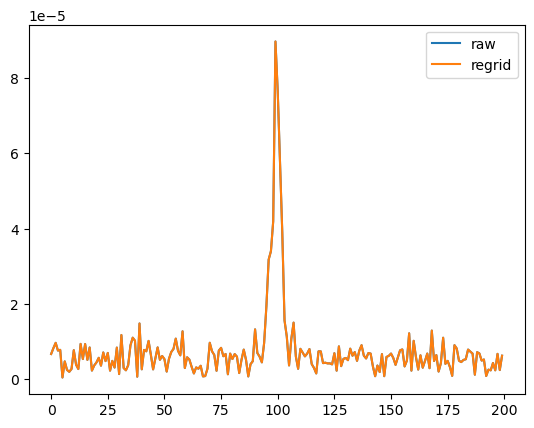

In [3]:
from fastmri_prostate.reconstruction.dwi.regridding import trapezoidal_regridding
print("hdr regrid params", hdr)
ks = kspace[0,0]  # one avg/slice
ks_rg = trapezoidal_regridding(ks, hdr)
print("pre", ks.shape, "post", ks_rg.shape, "mag stats", np.abs(ks_rg).mean(), np.abs(ks_rg).max())
# plot a central readout line before/after
plt.plot(np.abs(ks[0,:,ks.shape[-1]//2])); plt.plot(np.abs(ks_rg[0,:,ks_rg.shape[-1]//2])); plt.legend(["raw","regrid"])


In [5]:
hdr.keys()

dict_keys(['rampUpTime', 'rampDownTime', 'flatTopTime', 'acqDelayTime', 'echoSpacing', 'patient_id'])

In [62]:
from pathlib import Path
from datetime import datetime
import pandas as pd

from pathlib import Path
from datetime import datetime
import pandas as pd
import re

def human_to_bytes(s):
    """Convert '20K','3.4M','1.2G','512B','10MiB','2GiB' → bytes (float)."""
    if pd.isna(s):
        return pd.NA
    s = str(s).strip().lower()
    m = re.fullmatch(r'([\d.]+)\s*([kmgt]?i?b?)?', s)
    if not m:
        return pd.NA
    n = float(m.group(1))
    unit = (m.group(2) or '').replace('b', '')  # drop trailing 'b' if present

    # binary (Ki/Mi/Gi/Ti) vs decimal (K/M/G/T)
    binary = unit.endswith('i')
    unit = unit[:-1] if binary else unit
    base = 1024 if binary else 1000

    mult = {'': 1, 'k': base, 'm': base**2, 'g': base**3, 't': base**4}.get(unit, None)
    return n * mult if mult is not None else pd.NA

def parse_dat_filename(path: str):
    """
    Parse Siemens .dat filenames like:
    """
    p = Path(path)
    parts = p.stem.split("#")
    #data = {"path": str(p.resolve())}
    data = {}

    for part in parts:
        if part.startswith("S"):
            data["scanner_site"] = part[1:]
        elif part.startswith("F"):
            data["F_field"] = part[1:]
        elif part.startswith("M"):
            data["M_field"] = part[1:]
        elif re.fullmatch(r"D\d{6}", part): 
            data["date"] = datetime.strptime(part[1:], "%d%m%y").date().isoformat()
        elif re.fullmatch(r"T\d{6}", part):
            data["time"] = datetime.strptime(part[1:], "%H%M%S").time().isoformat()
        elif not part.startswith(("Hersh_VidaProstateDiffusion", "PidaProstateDiffusion")):
            data["modality"] = part
    
    data['fname_without_site'] = '#'.join([part for part in parts if not part.startswith("S")])

    if "date" in data and "time" in data:
        try:
            data["datetime"] = datetime.fromisoformat(f"{data['date']}T{data['time']}")
        except Exception:
            data["datetime"] = pd.NaT
    else:
        data["datetime"] = pd.NaT

    return data



In [63]:
parsed = df_all['path'].apply(parse_dat_filename).apply(pd.Series)
df_all = pd.concat([df_all, parsed], axis=1)

In [64]:
df_all["F_M"] = df_all["F_field"].astype(str) + "_" + df_all["M_field"].astype(str)
df_all["F_M_numeric"] = (
    pd.to_numeric(df_all["F_field"], errors="coerce") * 1_000_000 +
    pd.to_numeric(df_all["M_field"], errors="coerce")
)

df_all["size_bytes"] = df_all["size"].apply(human_to_bytes).astype("float64")

In [65]:
df_sorted = df_all.sort_values(["scanner_site", "datetime"], ascending=True).reset_index(drop=True)
df_sorted = df_sorted.reset_index(drop=True)

In [66]:
df_sorted['scanner_site'].value_counts().head()

scanner_site
41stVida2    5119
41stVida1    3664
41stVida3    3404
41Vida3      3228
CBIPrisma    2465
Name: count, dtype: int64

In [67]:
df_sorted[df_sorted['size'].str.contains('G')].shape, df_sorted.shape

((20225, 13), (35677, 13))

In [77]:
# Assume df has: scanner_site, F_field, M_field, datetime, size_bytes, modality, path
df_sorted = df_sorted.copy()
df_sorted["F_field"] = pd.to_numeric(df_sorted["F_field"], errors="coerce")
df_sorted["M_field"] = pd.to_numeric(df_sorted["M_field"], errors="coerce")
df_sorted["datetime"] = pd.to_datetime(df_sorted["datetime"])

# Classify prescan vs main by size (tune thresholds as needed)
PRESCAN_MAX = 100e6     # 100 MB
MAIN_MIN    = 1e9      # 1 GB

df_pres = df_sorted.loc[df_sorted["size_bytes"] < PRESCAN_MAX].copy()
df_main = df_sorted.loc[df_sorted["size_bytes"] > MAIN_MIN].copy()

df_main = (
    df_main.dropna(subset=["scanner_site","datetime"])
           .sort_values(["datetime","scanner_site"])
           .copy()
)

# Keep a right-side copy so we have both after merge
df_pres = (
    df_pres.dropna(subset=["scanner_site","datetime"])
           .sort_values(["datetime","scanner_site"])
           .copy()
)
df_pres["datetime_pre"] = df_pres["datetime"]

# Merge (join key stays 'datetime')
pairs = pd.merge_asof(
    left=df_main,
    right=df_pres,
    on="datetime",
    by="scanner_site",
    direction="nearest",
    tolerance=pd.Timedelta("5min"),
    suffixes=("_main", "_pre"),
)

# 2) Rename the join key to make it explicit
pairs = pairs.rename(columns={"datetime": "datetime_main"})

# 3) Deltas / score (adjust names if your columns differ)
pairs["dF"] = (pairs["F_field_main"] - pairs["F_field_pre"]).abs()
pairs["dM"] = (pairs["M_field_main"] - pairs["M_field_pre"]).abs()
pairs["delta_minutes"] = (pairs["datetime_main"] - pairs["datetime_pre"]).abs().dt.total_seconds() / 60

pairs["score"] = (
    2.0 * (pairs["dF"] != 1) +
    2.0 * (pairs["dM"] != 1) +
    0.5 * (pairs["dF"] > 1) +
    0.5 * (pairs["dM"] > 1)
)

# 4) Keep best prescan per main (optional)
pairs = (
    pairs.sort_values(["scanner_site","datetime_main","score"])
         .groupby(["scanner_site","path_main"], as_index=False)
         .first()
)

# 5) Select columns (ensure these names exist in your df; if you used 'size_bytes', change accordingly)
cols = [
    "scanner_site", "fname_without_site_main",
    "path_main", "size_main", "F_field_main", "M_field_main", "datetime_main", "modality_main",
    "path_pre",  "size_pre",  "F_field_pre",  "M_field_pre",  "datetime_pre",  "modality_pre",
    "dF", "dM", "delta_minutes", "score"
]
existing = [c for c in cols if c in pairs.columns]
pairs = pairs[existing]


In [78]:
pairs.head(n=3)

,scanner_site,fname_without_site_main,path_main,size_main,F_field_main,M_field_main,datetime_main,modality_main,path_pre,size_pre,F_field_pre,M_field_pre,datetime_pre,modality_pre,dF,dM,delta_minutes,score
0,1111VIDA1,Hersh_VidaProstateDiffusion#F100240#M264#D1909...,./1111VIDA1/Hersh_VidaProstateDiffusion/Hersh_...,3.6G,100240,264,2024-09-19 14:02:16,AXDIFFUSION_HVD,./1111VIDA1/Hersh_VidaProstateDiffusion/Hersh_...,1.3M,100239.0,263.0,2024-09-19 14:02:12,AXDIFFUSION_HVD,1.0,1.0,0.066667,0.0
1,1111VIDA1,Hersh_VidaProstateDiffusion#F102866#M385#D2609...,./1111VIDA1/Hersh_VidaProstateDiffusion/Hersh_...,3.8G,102866,385,2024-09-26 14:40:36,AXDIFFUSION_HVD,./1111VIDA1/Hersh_VidaProstateDiffusion/Hersh_...,1.3M,102865.0,384.0,2024-09-26 14:40:34,AXDIFFUSION_HVD,1.0,1.0,0.033333,0.0
2,1111VIDA1,Hersh_VidaProstateDiffusion#F10578#M847#D12122...,./1111VIDA1/Hersh_VidaProstateDiffusion/Hersh_...,4.6G,10578,847,2023-12-12 14:58:18,AXDIFFUSION_HVD,./1111VIDA1/Hersh_VidaProstateDiffusion/Hersh_...,1.3M,10577.0,846.0,2023-12-12 14:58:05,AXDIFFUSION_HVD,1.0,1.0,0.216667,0.0


In [79]:
pairs.shape

(20228, 18)

In [113]:
pairs = pairs.drop_duplicates(subset='fname_without_site_main')

In [115]:
priority = ['41stVida1', '41stVida2', '41stVida3', '41Vida1', '41Vida2', '41Vida3']

In [120]:
pairs_sorted = pairs.assign(
    sort_key=pairs['scanner_site'].apply(
        lambda x: priority.index(x) if x in priority else len(priority)
    )
).sort_values('sort_key').drop(columns='sort_key')

In [121]:
pairs_sorted.shape

(20168, 18)

## Check if filename (excluding site) is repeated (duplicates)

In [95]:
fname_counts_across_sites = pairs['fname_without_site_main'].value_counts()
fname_counts_across_sites_filtered = pairs[pairs['fname_without_site_main'].isin(fname_counts_across_sites[fname_counts_across_sites > 1].index)]

In [84]:
pairs.loc[pairs['fname_without_site_main'] == 'Hersh_VidaProstateDiffusion#F278728#M3855#D260623#T072237#AXDIFFUSION_HVD']

,scanner_site,fname_without_site_main,path_main,size_main,F_field_main,M_field_main,datetime_main,modality_main,path_pre,size_pre,F_field_pre,M_field_pre,datetime_pre,modality_pre,dF,dM,delta_minutes,score
1627,41Vida2,Hersh_VidaProstateDiffusion#F278728#M3855#D260...,./41Vida2/Hersh_VidaProstateDiffusion/Hersh_Vi...,3.6G,278728,3855,2023-06-26 07:22:37,AXDIFFUSION_HVD,./41Vida2/Hersh_VidaProstateDiffusion/Hersh_Vi...,1.3M,278727.0,3854.0,2023-06-26 07:22:35,AXDIFFUSION_HVD,1.0,1.0,0.033333,0.0
6395,41stVida2,Hersh_VidaProstateDiffusion#F278728#M3855#D260...,./41stVida2/Hersh_VidaProstateDiffusion/Hersh_...,3.6G,278728,3855,2023-06-26 07:22:37,AXDIFFUSION_HVD,./41stVida2/Hersh_VidaProstateDiffusion/Hersh_...,1.3M,278727.0,3854.0,2023-06-26 07:22:35,AXDIFFUSION_HVD,1.0,1.0,0.033333,0.0


In [100]:
pair_sites = set()
for i in fname_counts_across_sites_filtered['fname_without_site_main']:
    sites = '|'.join([j for j in fname_counts_across_sites_filtered.loc[fname_counts_across_sites_filtered['fname_without_site_main'] == i]['scanner_site'].tolist()])
    pair_sites.add(sites)

In [101]:
pair_sites

{'32ndVida|NotGiven',
 '41Vida2|41stVida2',
 '41Vida3|41stVida1',
 '41Vida3|41stVida3',
 'CBIPrisma|NotGiven',
 'NotGiven|VidaBayRidge',
 'Vida6Ohio|VidaOhio'}

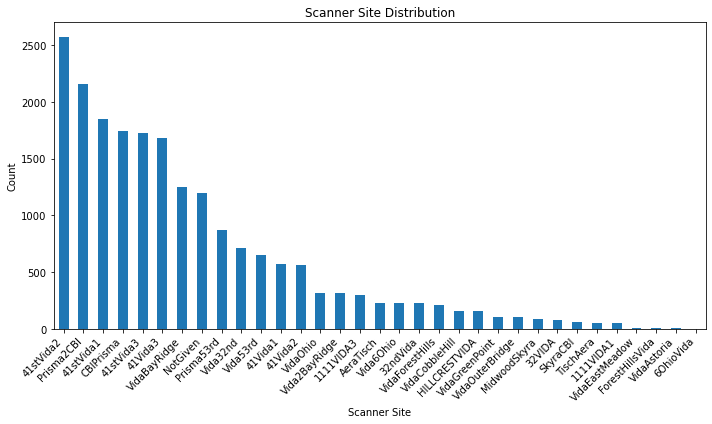

In [24]:
counts = pairs['scanner_site'].value_counts()

plt.figure(figsize=(10, 6))
counts.plot(kind='bar')
plt.title('Scanner Site Distribution')
plt.xlabel('Scanner Site')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

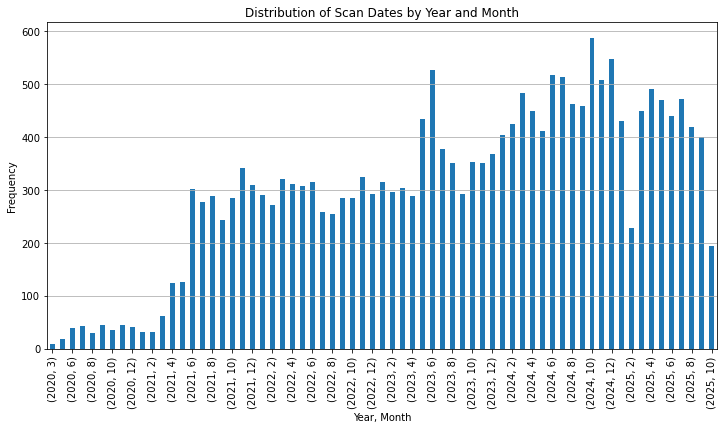

In [16]:
dates = pd.to_datetime(list(pairs['datetime_main']), format='%Y%m%d')

dates_df = pd.DataFrame({'Date': dates})

plt.figure(figsize=(12, 6))
dates_df.groupby([dates_df['Date'].dt.year, dates_df['Date'].dt.month]).size().plot(kind='bar')
plt.title('Distribution of Scan Dates by Year and Month')
plt.xlabel('Year, Month')
plt.ylabel('Frequency')
plt.xticks(rotation=90, ticks=plt.xticks()[0][::2])
plt.grid(axis='y')
plt.show()

In [33]:
2571+1851+1729

6151

In [32]:
pairs['scanner_site'].value_counts()

scanner_site
41stVida2          2571
Prisma2CBI         2155
41stVida1          1851
CBIPrisma          1742
41stVida3          1729
41Vida3            1677
VidaBayRidge       1251
NotGiven           1195
Prisma53rd          867
Vida32nd            712
Vida53rd            653
41Vida1             570
41Vida2             563
VidaOhio            319
Vida2BayRidge       312
1111VIDA3           299
AeraTisch           231
Vida6Ohio           229
32ndVida            228
VidaForestHills     213
VidaCobbleHill      159
HILLCRESTVIDA       156
VidaGreenPoint      105
VidaOuterBridge     100
MidwoodSkyra         85
32VIDA               77
SkyraCBI             63
TischAera            54
1111VIDA1            48
VidaEastMeadow        6
ForestHillsVida       4
VidaAstoria           3
6OhioVida             1
Name: count, dtype: int64

# Validate that ESC is correct

In [7]:

from fastmri_prostate.data.mri_data import load_dat_file_dwi
from fastmri_prostate.reconstruction.dwi.regridding import trapezoidal_regridding
from fastmri_prostate.reconstruction.grappa import Grappa
from fastmri_prostate.reconstruction.dwi.prostate_dwi_recon import dwi_reconstruction_esc

# --- inputs ---
dat_path = Path("/gpfs/scratch/td2105/dwi_stream/temp_dat_files/Hersh_VidaProstateDiffusion#S41stVida3#F113346#M337#D040520#T110349#AXDIFFUSION_HVD.dat")   
directions = ("b50x", "b1000x")             # directions to reconstruct
averages = (4, 12)                          # num b50 / b1000 averages


kspace, calibration, hdr = load_dat_file_dwi(dat_path)


Software version: VD/VE (!?)

Scan  0
100 % parsed in 46 s. Estimated 0 s remaining..


In [11]:
%%time
kspace_slice_regridded = trapezoidal_regridding(kspace[0, 0, ...], hdr)
grappa_obj = Grappa(np.transpose(kspace_slice_regridded, (2, 0, 1)), kernel_size=(5, 5), coil_axis=1)

grappa_weight_dict = {}
for slice_num in range(kspace.shape[1]):
    calibration_regridded = trapezoidal_regridding(calibration[slice_num, ...], hdr)
    grappa_weight_dict[slice_num] = grappa_obj.compute_weights(
        np.transpose(calibration_regridded, (2, 0 ,1))
    )
    if slice_num % 5 == 0:
        print('processed slice: ', slice_num)

post_grappa_img_vol = np.zeros(
    (kspace.shape[0], kspace.shape[1], kspace.shape[2], kspace.shape[3], kspace.shape[4]),
    dtype=np.complex64,
)

processed slice:  0
processed slice:  5
processed slice:  10
processed slice:  15
processed slice:  20
processed slice:  25
CPU times: user 1min 9s, sys: 1min 4s, total: 2min 14s
Wall time: 34.9 s


In [15]:
%%time
for average in range(kspace.shape[0]):
    for slice_num in range(kspace.shape[1]):
        kspace_slice_regridded = trapezoidal_regridding(kspace[average, slice_num, ...], hdr)
        kspace_post_grappa = grappa_obj.apply_weights(
            np.transpose(kspace_slice_regridded, (2, 0, 1)),
            grappa_weight_dict[slice_num]
        )

        kspace_coil_first = np.transpose(kspace_post_grappa, (1, 2, 0))
        coil_domain = np.fft.ifftshift(
            np.fft.ifftn(
                np.fft.fftshift(kspace_coil_first, axes=(1, 2)),
                axes=(1, 2),
            ),
            axes=(1, 2),
        )
        post_grappa_img_vol[average, slice_num] = coil_domain

    if average % 5 == 0:
        print("Processed {0} averages of {1}".format(average, kspace.shape[0]))


Processed 0 averages of 50
Processed 5 averages of 50
Processed 10 averages of 50
Processed 15 averages of 50
Processed 20 averages of 50
Processed 25 averages of 50
Processed 30 averages of 50
Processed 35 averages of 50
Processed 40 averages of 50
Processed 45 averages of 50
CPU times: user 7min 14s, sys: 8min 3s, total: 15min 17s
Wall time: 5min 44s


In [18]:
post_grappa_img_vol.shape, type(post_grappa_img_vol)

((50, 30, 20, 200, 150), numpy.ndarray)

In [37]:
import math
import matplotlib.pyplot as plt
import numpy as np

def plot_coil_grid(coil_volume: np.ndarray, average_idx: int, slice_idx: int, n_cols: int = 5) -> None:
    """
    Show all coil images for a given (average, slice) pair.

    Parameters
    ----------
    coil_volume : np.ndarray
        Array of shape (num_averages, num_slices, num_coils, height, width).
    average_idx : int
        Index of the average to display.
    slice_idx : int
        Index of the slice to display.
    n_cols : int
        Number of columns in the subplot grid (default 5).
    """
    n_avg, n_slices, n_coils, _, _ = coil_volume.shape

    coil_imgs = np.abs(coil_volume[average_idx, slice_idx])  # shape (n_coils, H, W)
    n_rows = math.ceil(n_coils / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax_idx, ax in enumerate(axes):
        if ax_idx < n_coils:
            ax.imshow(coil_imgs[ax_idx], cmap="gray")
            ax.set_title(f"Coil {ax_idx}", fontsize=9)
            ax.axis("off")
        else:
            ax.set_visible(False)

    fig.suptitle(f"Average {average_idx}, Slice {slice_idx}", fontsize=14)
    plt.tight_layout()
    plt.show()

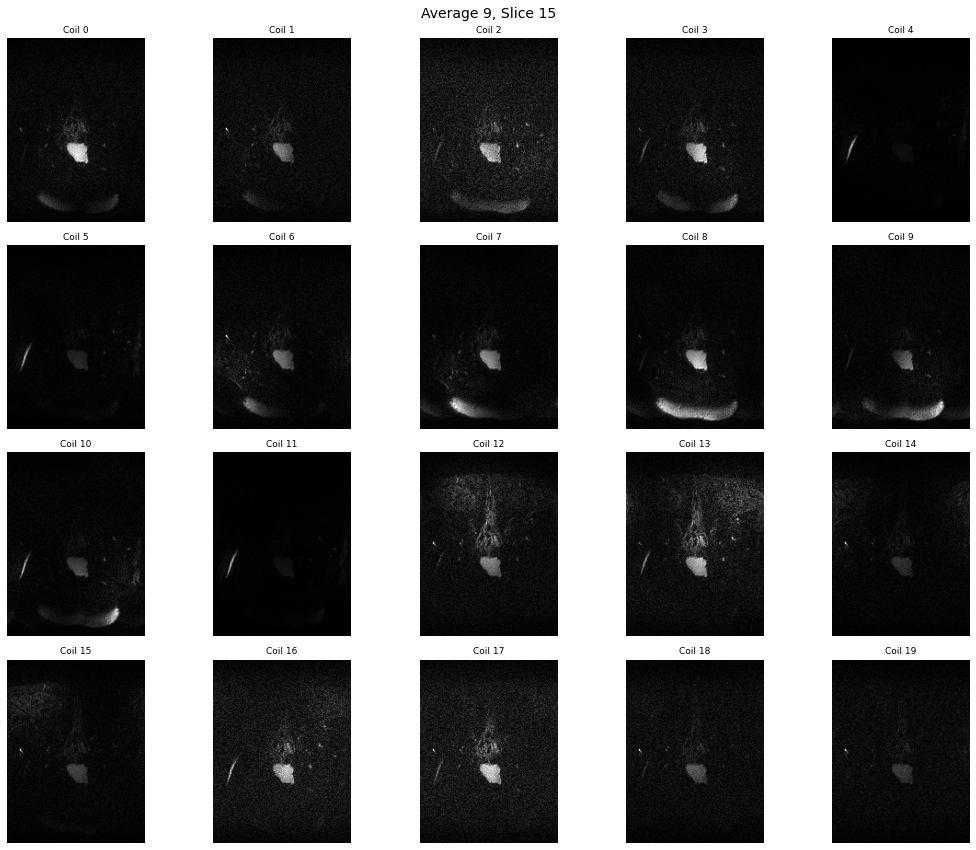

In [47]:
plot_coil_grid(post_grappa_img_vol, average_idx=9, slice_idx=15)

In [24]:
rss_vol = np.sqrt(
    np.sum(
        np.abs(post_grappa_img_vol) ** 2,
        axis=2,
        dtype=np.float32,
    )
)

In [25]:
rss_vol.shape

(50, 30, 200, 150)

In [29]:
def compute_averages(img_vol: np.ndarray):
    num_averages = img_vol.shape[0]
    offset = 2 if num_averages == 48 else 0

    def slice_range(start, stop, step):
        idx = np.arange(start, stop, step) - offset
        return idx[(idx >= 0) & (idx < num_averages)]

    def avg(indices, count):
        return np.mean(img_vol[indices[:count], ...], axis=0)

    return {
        "b50x": avg(slice_range(2, 22, 6), 4),
        "b50y": avg(slice_range(3, 23, 6), 4),
        "b50z": avg(slice_range(4, 24, 6), 4),
        "b1000x": avg(
            np.concatenate([slice_range(5, 25, 6), slice_range(26, 48, 3)]),
            12,
        ),
        "b1000y": avg(
            np.concatenate([slice_range(6, 26, 6), slice_range(27, 49, 3)]),
            12,
        ),
        "b1000z": avg(
            np.concatenate([slice_range(7, 27, 6), slice_range(28, 50, 3)]),
            12,
        ),
    }

In [30]:
final_vol = compute_averages(rss_vol)

In [32]:
final_vol.keys()

dict_keys(['b50x', 'b50y', 'b50z', 'b1000x', 'b1000y', 'b1000z'])

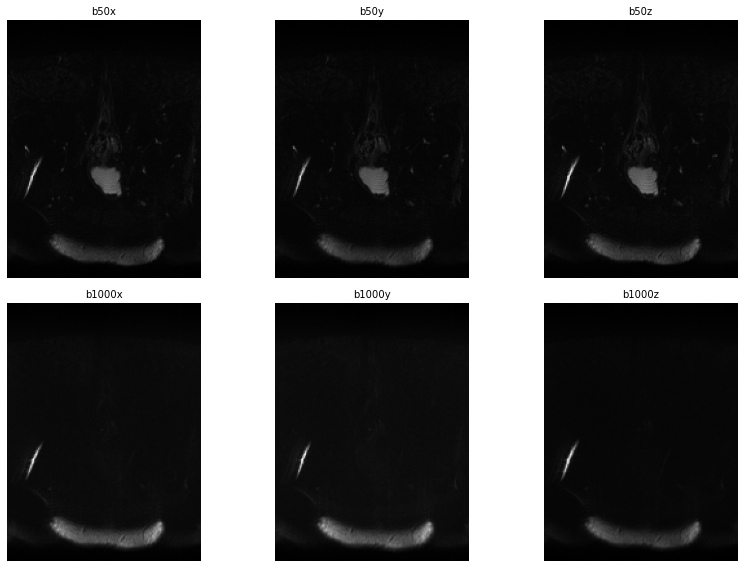

In [36]:
import matplotlib.pyplot as plt

directions = list(final_vol.keys())
slice_idx = 15

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, direction in zip(axes.ravel(), directions):
    vol = final_vol[direction]
    if slice_idx >= vol.shape[0]:
        ax.set_visible(False)
        continue
    ax.imshow(vol[slice_idx], cmap="gray")
    ax.set_title(direction, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

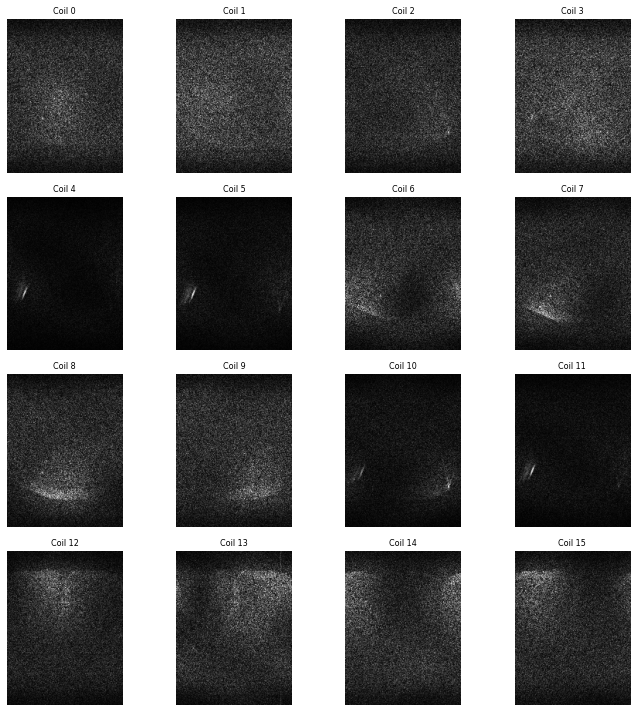

In [28]:
coil_stack = np.abs(result.post_grappa_coil_images)  # (avg, slice, coil, H, W)
avg_idx = 6
slice_idx = 10
n_show = min(16, coil_stack.shape[2])

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, coil_img, coil_id in zip(axes.ravel(), coil_stack[avg_idx, slice_idx, :n_show], range(n_show)):
    ax.imshow(coil_img, cmap="gray")
    ax.set_title(f"Coil {coil_id}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Validate ESC/RSS/ESPIRIT

In [7]:
def load_h5_with_shapes(path):
    """Return nested dict of datasets; print path/shape/dtype as we go."""
    def _walk(group, prefix=""):
        out = {}
        for key, item in group.items():
            name = f"{prefix}/{key}" if prefix else key
            if isinstance(item, h5py.Dataset):
                print(f"{name}: shape={item.shape}, dtype={item.dtype}")
                out[key] = item[()]  
            elif isinstance(item, h5py.Group):
                out[key] = _walk(item, name)
        return out

    with h5py.File(path, "r") as f:
        return _walk(f)

In [24]:
dfp = pd.read_csv('/gpfs/data/prostatelab/Patricia/Prostate_MRI_csvs/MRI_List_TextRadReports.csv')
dicom_h5_root = '/gpfs/data/prostatelab/processed_data/h5/t2_dwi_filtered_2024_data_20250408'
dfp['PatientID'] = dfp['PatientID'].astype(str)
print(dfp[dfp['PatientID'].isin(h5_mrn)].shape)

path_to_h5 = '/gpfs/scratch/td2105/dwi_stream/recons_v2'
h5_files = list(Path(path_to_h5).glob('*.h5'))

h5_mrn = [i.stem.split('__')[-1] for i in h5_files]

contents = load_h5_with_shapes(h5_files[0])
h5_mrn

(16, 5)
coil/post_grappa_full: shape=(48, 33, 24, 200, 150), dtype=float32
hdr: shape=(), dtype=object
images/esc/b50_1_b1000_1/b1000x: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_1/b1000y: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_1/b1000z: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_1/b50x: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_1/b50y: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_1/b50z: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_2/b1000x: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_2/b1000y: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_2/b1000z: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_2/b50x: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_2/b50y: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_2/b50z: shape=(33, 100, 100), dtype=float32
images/esc/b50_1_b1000_3/b1000x: shape=(33, 100, 100), dtype=float32
images/esc/b

['8931988',
 '5282049',
 '16700551',
 '2649468',
 '14409543',
 '16385592',
 '11640034']

In [38]:
map_mrn_dicom = {}
for i in h5_files:
    h5_mrn = i.stem.split('__')[-1]
    if h5_mrn in ['8931988', '5282049', '14409543']:
        acc = dfp[dfp['PatientID'] == h5_mrn].iloc[0]['AccessionNumber']
        acc_path = Path(dicom_h5_root) / f"{acc}.h5"
        map_mrn_dicom[str(i)] = str(acc_path)
map_mrn_dicom

{'/gpfs/scratch/td2105/dwi_stream/recons_v2/Hersh_VidaProstateDiffusion#S41stVida1#F42022#M2556#D040524#T092557#AXDIFFUSION_HVD__8931988.h5': '/gpfs/data/prostatelab/processed_data/h5/t2_dwi_filtered_2024_data_20250408/42734880.h5',
 '/gpfs/scratch/td2105/dwi_stream/recons_v2/Hersh_VidaProstateDiffusion#S41stVida1#F418755#M2705#D160124#T075901#AXDIFFUSION_HVD__5282049.h5': '/gpfs/data/prostatelab/processed_data/h5/t2_dwi_filtered_2024_data_20250408/40268491.h5',
 '/gpfs/scratch/td2105/dwi_stream/recons_v2/Hersh_VidaProstateDiffusion#S41stVida1#F419987#M3937#D160124#T203840#AXDIFFUSION_HVD__14409543.h5': '/gpfs/data/prostatelab/processed_data/h5/t2_dwi_filtered_2024_data_20250408/40314150.h5'}

In [55]:
import h5py, numpy as np, matplotlib.pyplot as plt

def plot_adc_b1500_pair(recon_h5, dicom_h5, tag=None, slice_index=None):
    with h5py.File(recon_h5, "r") as frecon, h5py.File(dicom_h5, "r") as fdicom:
        combines = [c.decode(errors="ignore") if isinstance(c, bytes) else str(c) for c in frecon["metadata/combines"][()]]
        combines = [c for c in combines if c != "espirit"]
        tags = [t.decode(errors="ignore") if isinstance(t, bytes) else str(t) for t in frecon["metadata/averaging_schemes"][()]]
        use_tag = tag or tags[0]
        if use_tag not in tags:
            raise ValueError(f"Tag '{use_tag}' not found. Available: {tags}")

        def pick_slice(vol, idx):
            if vol.ndim == 2:
                return 0, vol
            z = vol.shape[0]
            idx = z // 2 if idx is None else max(0, min(idx, z - 1))
            return idx, vol[idx]

        # DICOM: slices on last axis -> move to front
        adc_dicom = np.moveaxis(fdicom["adc"][()], -1, 0)
        b1500_dicom = np.moveaxis(fdicom["b1500"][()], -1, 0)
        dicom_idx, adc_d_slice = pick_slice(adc_dicom, slice_index)
        _, b1500_d_slice = pick_slice(b1500_dicom, dicom_idx)

        ncols = 1 + len(combines)  # first column = DICOM
        fig, axes = plt.subplots(2, ncols, figsize=(3 * ncols, 6), squeeze=False)

        # DICOM column
        axes[0, 0].imshow(adc_d_slice, cmap="gray"); axes[0, 0].set_title(f"DICOM ADC (slice {dicom_idx})"); axes[0, 0].axis("off")
        axes[1, 0].imshow(b1500_d_slice, cmap="gray"); axes[1, 0].set_title(f"DICOM b1500 (slice {dicom_idx})"); axes[1, 0].axis("off")

        # Recon columns
        for col, combine in enumerate(combines, start=1):
            adc_recon = np.flip(frecon[f"metrics/{combine}/{use_tag}/adc_map"][()], axis=-1)
            b1500_recon = np.flip(frecon[f"metrics/{combine}/{use_tag}/b1500"][()], axis=-1)
            recon_idx, adc_r_slice = pick_slice(adc_recon, slice_index)
            _, b1500_r_slice = pick_slice(b1500_recon, recon_idx)

            axes[0, col].imshow(adc_r_slice, cmap="gray"); axes[0, col].set_title(f"{combine} ADC (slice {recon_idx})"); axes[0, col].axis("off")
            axes[1, col].imshow(b1500_r_slice, cmap="gray"); axes[1, col].set_title(f"{combine} b1500 (slice {recon_idx})"); axes[1, col].axis("off")

        plt.tight_layout()
        plt.show()


In [58]:
pairs = list(map_mrn_dicom.items())
pairs

[('/gpfs/scratch/td2105/dwi_stream/recons_v2/Hersh_VidaProstateDiffusion#S41stVida1#F42022#M2556#D040524#T092557#AXDIFFUSION_HVD__8931988.h5',
  '/gpfs/data/prostatelab/processed_data/h5/t2_dwi_filtered_2024_data_20250408/42734880.h5'),
 ('/gpfs/scratch/td2105/dwi_stream/recons_v2/Hersh_VidaProstateDiffusion#S41stVida1#F418755#M2705#D160124#T075901#AXDIFFUSION_HVD__5282049.h5',
  '/gpfs/data/prostatelab/processed_data/h5/t2_dwi_filtered_2024_data_20250408/40268491.h5'),
 ('/gpfs/scratch/td2105/dwi_stream/recons_v2/Hersh_VidaProstateDiffusion#S41stVida1#F419987#M3937#D160124#T203840#AXDIFFUSION_HVD__14409543.h5',
  '/gpfs/data/prostatelab/processed_data/h5/t2_dwi_filtered_2024_data_20250408/40314150.h5')]

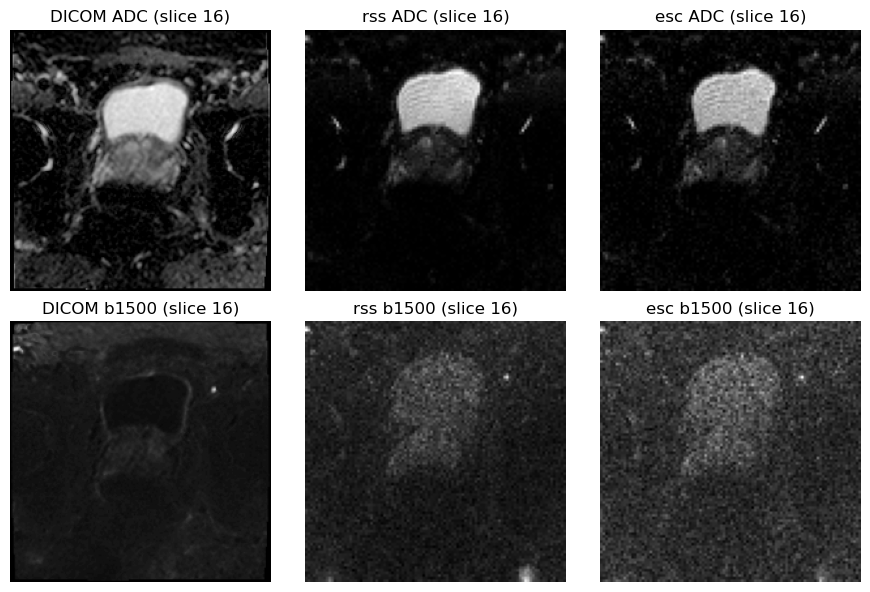

In [60]:
recon_path, proc_path = pairs[0]
plot_adc_b1500_pair(recon_path, proc_path, tag="b50_1_b1000_1", slice_index=None)

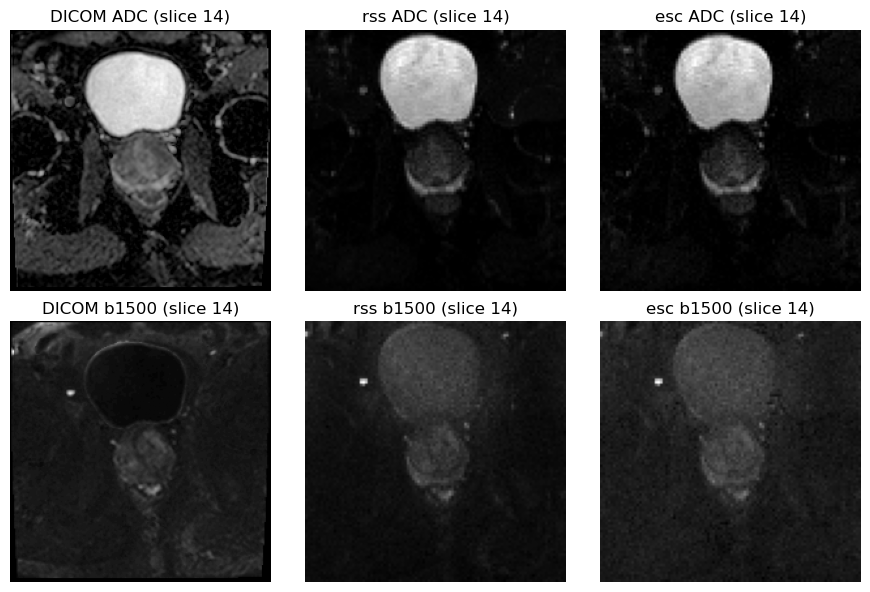

In [63]:
recon_path, proc_path = pairs[2]
plot_adc_b1500_pair(recon_path, proc_path, tag="b50_4_b1000_12", slice_index=None)

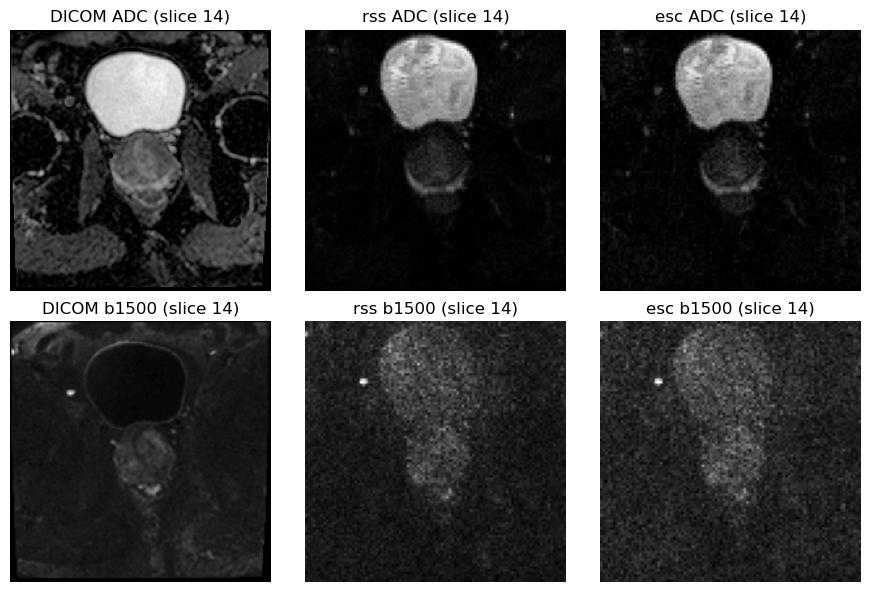

In [64]:
recon_path, proc_path = pairs[2]
plot_adc_b1500_pair(recon_path, proc_path, tag="b50_1_b1000_1", slice_index=None)